First 5 rows of the Iris dataset:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   species species_name  
0        0       setosa  
1        0       setosa  
2        0       setosa  
3        0       setosa  
4        0       setosa  

Species names (what we're trying to predict):
['setosa' 'versicolor' 'virginica']
Dataset Info (shows columns, non-null counts, data types):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -

<Figure size 1000x800 with 0 Axes>

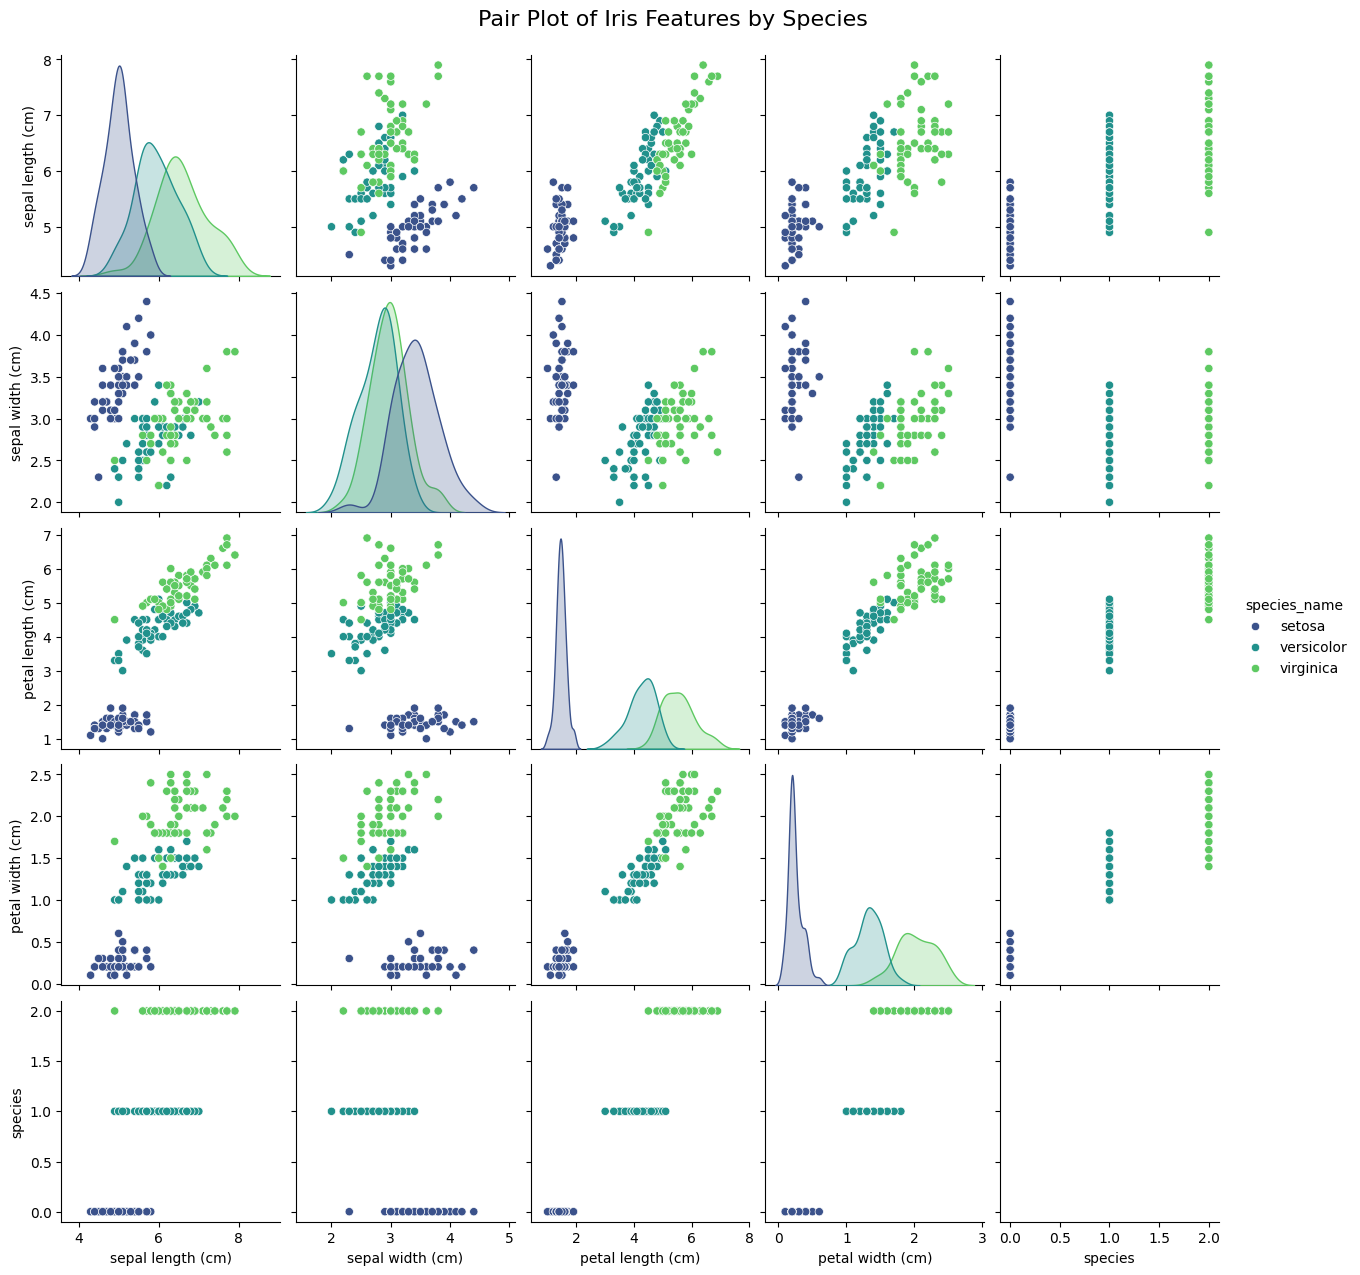

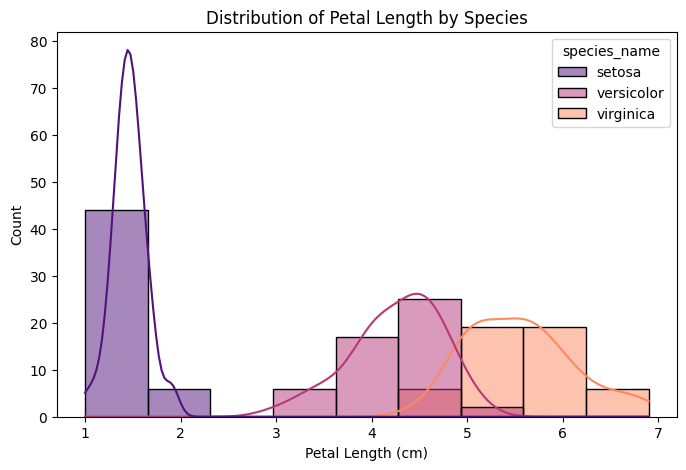

Shape of X_train (training features): (120, 4)
Shape of X_test (testing features): (30, 4)
Shape of y_train (training species labels): (120,)
Shape of y_test (testing species labels): (30,)
Training the K-Nearest Neighbors model...
Model training complete!
Model Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30


Confusion Matrix (Actual vs. Predicted):


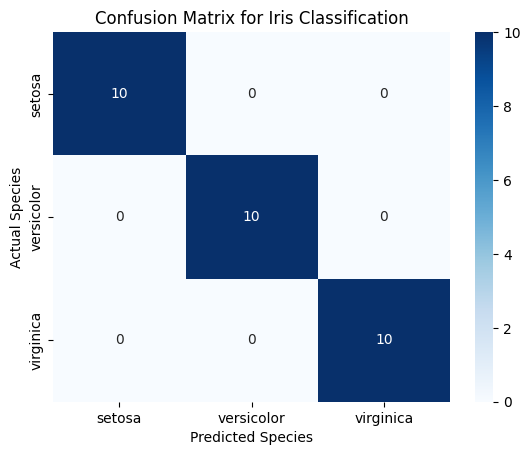

New flower measurements:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.5               2.5                4.0               1.3

Predicted species for the new flower: versicolor


In [3]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.model_selection import train_test_split 
from sklearn.neighbors import KNeighborsClassifier 
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix 
from sklearn.datasets import load_iris 


np.random.seed(42)


iris = load_iris()


X = iris.data

y = iris.target


feature_names = iris.feature_names

target_names = iris.target_names


df = pd.DataFrame(X, columns=feature_names)
df['species'] = y 


df['species_name'] = df['species'].map({0: target_names[0], 1: target_names[1], 2: target_names[2]})

print("First 5 rows of the Iris dataset:")
print(df.head())

print("\nSpecies names (what we're trying to predict):")
print(target_names)


print("Dataset Info (shows columns, non-null counts, data types):")
df.info()

print("\nStatistical Summary (shows mean, min, max, etc. for numerical columns):")
print(df.describe())

print("\nSpecies Distribution (how many flowers of each species are there):")
print(df['species_name'].value_counts())


plt.figure(figsize=(10, 8))
sns.pairplot(df, hue='species_name', palette='viridis') # 'hue' colors points by species
plt.suptitle('Pair Plot of Iris Features by Species', y=1.02, fontsize=16) # Add a title above the plot
plt.show()


plt.figure(figsize=(8, 5))
sns.histplot(df, x='petal length (cm)', hue='species_name', kde=True, palette='magma')
plt.title('Distribution of Petal Length by Species')
plt.xlabel('Petal Length (cm)')
plt.ylabel('Count')
plt.show()



X = df[feature_names] # Selecting only the measurement columns
y = df['species'] # Selecting the numerical species column


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Shape of X_train (training features): {X_train.shape}")
print(f"Shape of X_test (testing features): {X_test.shape}")
print(f"Shape of y_train (training species labels): {y_train.shape}")
print(f"Shape of y_test (testing species labels): {y_test.shape}")


knn_model = KNeighborsClassifier(n_neighbors=3)


print("Training the K-Nearest Neighbors model...")
knn_model.fit(X_train, y_train)
print("Model training complete!")


y_pred = knn_model.predict(X_test)


accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f}") 


print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=target_names))


print("\nConfusion Matrix (Actual vs. Predicted):")
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted Species')
plt.ylabel('Actual Species')
plt.title('Confusion Matrix for Iris Classification')
plt.show()


new_flower_measurements = np.array([[5.5, 2.5, 4.0, 1.3]]) # Example measurements


new_flower_df = pd.DataFrame(new_flower_measurements, columns=feature_names)

print("New flower measurements:")
print(new_flower_df)


predicted_species_num = knn_model.predict(new_flower_df)


predicted_species_name = target_names[predicted_species_num[0]]

print(f"\nPredicted species for the new flower: {predicted_species_name}")